<a href="https://colab.research.google.com/github/codeyson/CPE-313/blob/main/Hands_on_Activity_5_2_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [1]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets

categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

In [2]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [4]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [5]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [6]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [7]:
with open('ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [8]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [9]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [11]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [12]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20)


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [13]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

The procedure shows the step by step process of using LDA. First, the first example came from a fetched file, the second one uses a text file. The process requires us to split hte text first. Then, use LDA to incorporate a topic for a block from the splitted text. Lastly, add feature_name to be assigned in the topics created.

#### Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

In [130]:
with open('baek.txt','r') as f:
    raw_text = f.read()

# remove speaker header
raw_text = re.sub(r"(psychiatrist|me)\s*:", "", raw_text, flags=re.I)
raw_text = re.sub(r"\b(psychiatrist|me)\b", "", raw_text, flags=re.I)

docs = raw_text.split('.')
docs[1]

' Two, that\nthere is no real way to separate these feelings\ncompletely from ourselves'

In [131]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'two, that there is no real way to separate these feelings completely from ourselves'

In [132]:
print(len(docs))

982


In [133]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer_baek = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer_baek.fit_transform(docs)

In [148]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 10
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [146]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer_baek.get_feature_names_out(),20)


Topic  0
said, better, friend, sad, kept, time, day, did, let, feel, know, wouldn, ashamed, thinking, don know, really, asked, tell, yes, life

Topic  1
things, think, going, really, don, doing, stop, happy, ve, reasons, tattoo, college, don think, night, anymore, person, like, mirror, face, high

Topic  2
ve, just, friend, think, thought, like, person, emotions, little, makes, work, want, getting, oh, drunk, instead, told, thing, ended, did

Topic  3
right, time, say, think, person, standards, kind, having, ll, really, hard, time time, high, moment, liked, happy, matter, extreme, today, anxious

Topic  4
feel, way, feeling, does, writing, attention, tired, make, love, scared, likes, hate, relationship, day, feel way, act, depressed, ordinary, enjoy, forth

Topic  5
just, thing, mood, home, make, people, body, harder, friends, absolutely, read, away, comfortable, moment, said, feels, meeting, sure, depression, phone

Topic  6
like, feel, don, good, did, want, know, people, person, thi

In [136]:
tn_baek = ["Depression",None,"Therapy",None,"Daily Life","Work Stress","Anxiety","Loneliness","Self Esteem","Personal Thoughts","Relationships","Overthinking",
      None,"Habits","Family","Social Pressure","Mental Health","Food","Emotions","Happiness","Healing",
      "Advertisements","Mood","Memories",None]

display_topics(lda,count_vectorizer_baek.get_feature_names_out(),20,topic_names=tn_baek)


Topic: ' Depression '
said, better, friend, sad, kept, time, day, did, let, feel, know, wouldn, ashamed, thinking, don know, really, asked, tell, yes, life

Topic  1
things, think, going, really, don, doing, stop, happy, ve, reasons, tattoo, college, don think, night, anymore, person, like, mirror, face, high

Topic: ' Therapy '
ve, just, friend, think, thought, like, person, emotions, little, makes, work, want, getting, oh, drunk, instead, told, thing, ended, did

Topic  3
right, time, say, think, person, standards, kind, having, ll, really, hard, time time, high, moment, liked, happy, matter, extreme, today, anxious

Topic: ' Daily Life '
feel, way, feeling, does, writing, attention, tired, make, love, scared, likes, hate, relationship, day, feel way, act, depressed, ordinary, enjoy, forth

Topic: ' Work Stress '
just, thing, mood, home, make, people, body, harder, friends, absolutely, read, away, comfortable, moment, said, feels, meeting, sure, depression, phone

Topic: ' Anxiety '

In [147]:
num_top_documents = 2

for topic_idx in range(n_topics):

    top_doc_indices = data[:, topic_idx].argsort()[::-1]

    print("\nTopic", topic_idx,
          "-", tn_baek[topic_idx] if tn_baek and tn_baek[topic_idx] else "")

    for i in range(num_top_documents):
        doc_index = top_doc_indices[i]
        print("\nDoc", doc_index)
        print(docs[doc_index])


Topic 0 - Depression

Doc 14
art has given  faith: faith that today may not have been perfect but was still a pretty good day, or faith that even after a long day of being depressed, i can still burst into laughter over something very small

Doc 43
how did that make you feel?  desperate? sad? i felt like my family kept secrets i couldn’t tell anyone, secrets that kept growing bigger

Topic 1 - 

Doc 41
they have this euphemism for it now, ‘marital disputes’, but it’s just violence, isn’t it? when i think back on my childhood, my memories are full of my father beating my mother and my sisters and , smashing up the apartment and leaving the house in the middle of the night

Doc 444
that period disappeared from my conscious mind, but given that i have a habit of scrubbing my elbows every night and checking in the mirror countless times during the day to see if i have anything on my face, the memories must linger subconsciously

Topic 2 - Therapy

Doc 6
so i decided, instead of aimlessly 

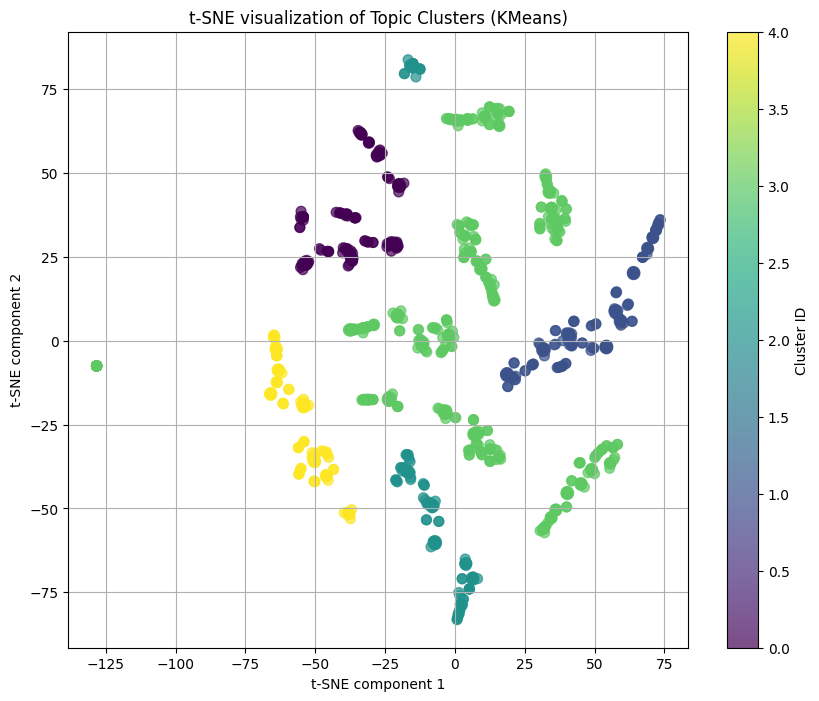

In [149]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

kmeans_model = KMeans(n_clusters=5, init='k-means++', max_iter=100, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(data)

tsne_model = TSNE(n_components=2, perplexity=10, learning_rate=200, random_state=42, init='pca')
X_tsne = tsne_model.fit_transform(data)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)
plt.title('t-SNE visualization of Topic Clusters (KMeans)')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.show()

#### Conclusion
> In this activity, I learned how to use my own dataset with LDA by following the procedure given in the notebook. I was amazed by how the model can find topics from the text automatically. By looking at the result, I think the model did a good job assigning topics to the split text. I analyzed topic 2 (therapy), and I concluded that the text talks about the process of thinking about her life and what she should do. I also used AI to help with debugging and building the visualization part.